In [1]:
# All paths relatibve the the JETSCAPE-FNO repo root (and comon layout), which we add to sys.path so we can import pyjetscape_core
# Needed for jupyter notebooks!!!

import os, sys

os.chdir("../build_conda") #or whatever your build directory is ...

_REPO_ROOT = os.path.abspath("../")

sys.path.insert(0, _REPO_ROOT)
sys.path.insert(0, os.path.join(_REPO_ROOT, "python"))

print("Working directory:", os.getcwd())

Working directory: /home/putschke/JetScape/JETSCAPE-FNO/build_conda


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from jetscape import create_module, InitialState
from jetscape.run_jetscape import run_manual

In [3]:
ini = create_module("TrentoInitial")   # typed as TrentoInitial
preeq = create_module("NullPreDynamics")
hydro = create_module("MUSIC")

hydro.set_preserve_bulk_info(True) 
# remark, this is really not working as fully intended, since it only keeps that last event info, not per event, have to change worklow inside jetscape Exec() ...

In [4]:
js = run_manual(
        "../config/jetscape_main.xml", "../fno_hydro/config/jetscape_user_root_bulk_test.xml",
        [ini, preeq, hydro],
        n_events=2
    )

[Info] *--------------------------------------------------------------*
[Info] |                                                              |
[Info] |                  /\                                          |
[Info] |                 /  \                                         |
[Info] |                / |  \                                        |
[Info] |               /  |   \              /\                       |
[Info] |              /   |    \          /\/  \                      |
[Info] |             / \  |  /  \      /\/   |  \/\                   |
[Info] |            /   \ | /    \    /    % | %   \                  |
[Info] |         __/     \|/      \__/      %|%     \/\__             |
[Info] |                                                              |
[Info] |                          JETSCAPE                            |
[Info] |                                                              |
[Info] |     The Jet Energy-loss Tomography with a Statistically

In [5]:
 # Print per-event geometry info when using TrentoInitial
try:
    info = ini.get_event_info()
    print("  TrentoInitial event info:")
    print(f"    impact_parameter     = {info['impact_parameter']:.3f} fm")
    print(f"    num_participant      = {info['num_participant']:.1f}")
    print(f"    num_binary_collisions= {info['num_binary_collisions']:.1f}")
    print(f"    total_entropy        = {info['total_entropy']:.2f}")
    print(f"    event_centrality     = {info['event_centrality']:.1f} %")
except AttributeError:
    pass  # GaussianIC — no event info

  TrentoInitial event info:
    impact_parameter     = 5.133 fm
    num_participant      = 275.0
    num_binary_collisions= 626.0
    total_entropy        = 784.19
    event_centrality     = 7.5 %


In [6]:
def extract_bulk_numpy(hydro, n_features: int) -> "np.ndarray":
    """
    Extract EvolutionHistory as a numpy array.

    Returns
    -------
    np.ndarray, shape (ntau, nx, ny, n_features), dtype float32
    """
    from jetscape.utils import bulk_info_to_numpy
    bulk = hydro.get_bulk_info()
    arr  = bulk_info_to_numpy(bulk, n_features)
    return arr

def print_summary(arr: "np.ndarray", n_features: int) -> None:
    """Print a concise summary of the bulk_info array to stdout."""
    import numpy as np

    ntau, nx, ny, _ = arr.shape
    feature_names = ["energy_density", "temperature", "vx", "vy",
                     "entropy_density", "pressure"]

    print(f"\n{'='*55}")
    print(f"  bulk_info summary")
    print(f"{'='*55}")
    print(f"  Array shape : {arr.shape}  (ntau, nx, ny, n_features)")
    print(f"  dtype       : {arr.dtype}")
    print(f"  Memory      : {arr.nbytes / 1024**2:.2f} MB")
    print()
    for f in range(n_features):
        data = arr[:, :, :, f]
        name = feature_names[f] if f < len(feature_names) else f"feat_{f}"
        print(f"  {name:<20}  min={data.min():+.4f}  "
              f"max={data.max():+.4f}  mean={data.mean():+.4f}")
    print(f"{'='*55}\n")


In [7]:
bulk_info_obj = hydro.get_bulk_info()

# Try to read grid metadata
try:
    dtau    = bulk_info_obj.dtau
    tau_min = bulk_info_obj.tau_min
except AttributeError:
    pass  # use defaults above

print(f"  Extracting {3} features from bulk_info ...")
arr = extract_bulk_numpy(hydro, 3)

  Extracting 3 features from bulk_info ...


In [8]:
print_summary(arr, 3)


  bulk_info summary
  Array shape : (488, 150, 150, 3)  (ntau, nx, ny, n_features)
  dtype       : float32
  Memory      : 125.66 MB

  energy_density        min=+0.0000  max=+13.7905  mean=+0.0964
  temperature           min=+0.0001  max=+0.3060  mean=+0.0595
  vx                    min=-1.0000  max=+1.0000  mean=+0.0036



In [9]:
def plot_temperature_profile(
    arr: "np.ndarray",
    dtau: float,
    tau_min: float,
    outdir: str,
    plt,
) -> None:
    """
    Plot temperature (feature 1) integrated over the transverse plane vs τ.
    """
    if arr.shape[3] < 2:
        print("  [!] n_features < 2 — skipping temperature plot.")
        return

    import numpy as np

    ntau  = arr.shape[0]
    tau_v = tau_min + dtau * np.arange(ntau)
    T_max = arr[:, :, :, 1].max(axis=(1, 2))   # peak temperature vs τ
    T_slice = arr[:, :, :, 1]
    T_avg = np.array([
        T_slice[i][T_slice[i] > 0.01].mean() if (T_slice[i] > 0.01).any() else 0.0
        for i in range(ntau)
    ])  # spatial average vs τ only for T>0

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(tau_v, T_max, label="T_max(τ)",  lw=2)
    ax.plot(tau_v, T_avg, label="T_avg(τ)",  lw=2, ls="--")
    ax.axhline(0.136, color="red", ls=":", label="T_freeze = 0.136 GeV")
    ax.set_xlabel("τ  [fm/c]")
    ax.set_ylabel("Temperature  [GeV]")
    ax.set_title("Temperature evolution (spatial max and mean)")
    ax.legend()
    ax.grid(True, alpha=0.4)
    fig.tight_layout()

    #path = os.path.join(outdir, "temperature_profile.png")
    #fig.savefig(path, dpi=150)
    #print(f"  Saved → {path}")
    #plt.close(fig)


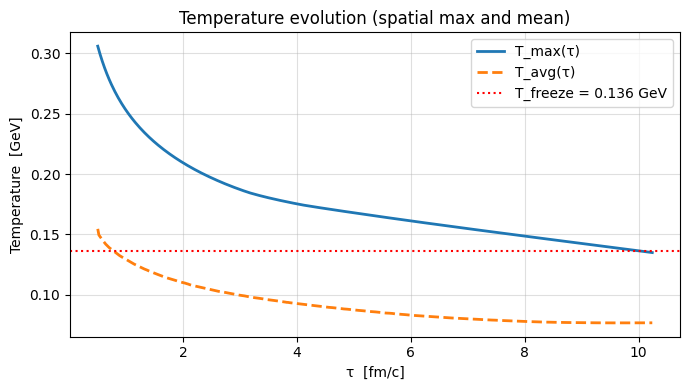

In [10]:
plot_temperature_profile(arr, dtau, tau_min, "./", plt)

In [11]:
def plot_energy_density_slices(
    arr: "np.ndarray",
    dtau: float,
    tau_min: float,
    outdir: str,
    plt,
) -> None:
    """
    Plot energy density (feature 0) at τ_start, τ_mid, τ_end.

    Parameters
    ----------
    arr     : (ntau, nx, ny, n_features)
    dtau    : proper-time step in fm/c
    tau_min : starting proper time in fm/c
    outdir  : output directory
    plt     : matplotlib.pyplot module
    """
    import numpy as np

    ntau, nx, ny, _ = arr.shape
    tau_values = tau_min + dtau * np.arange(ntau)

    step_indices = [0, ntau // 4, ntau // 2] #, 3 * ntau // 4, ntau - 1]
    step_indices = sorted(set(max(0, min(ntau - 1, s)) for s in step_indices))

    n_cols = len(step_indices)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))
    if n_cols == 1:
        axes = [axes]

    for ax, k in zip(axes, step_indices):
        ed = arr[k, :, :, 0]   # energy density
        vmin, vmax = 0.0, arr[k, :, :, 0].max()
        im = ax.imshow(
            ed.T, origin="lower", cmap="inferno",
            vmin=vmin, vmax=vmax,
            extent=[-nx / 2, nx / 2, -ny / 2, ny / 2],
        )
        fig.colorbar(im, ax=ax, label="e  [GeV/fm³]", shrink=0.85)
        ax.set_title(f"τ = {tau_values[k]:.2f} fm/c")
        ax.set_xlabel("x index")
        ax.set_ylabel("y index")

    fig.suptitle("Energy density evolution", fontsize=14)
    fig.tight_layout()

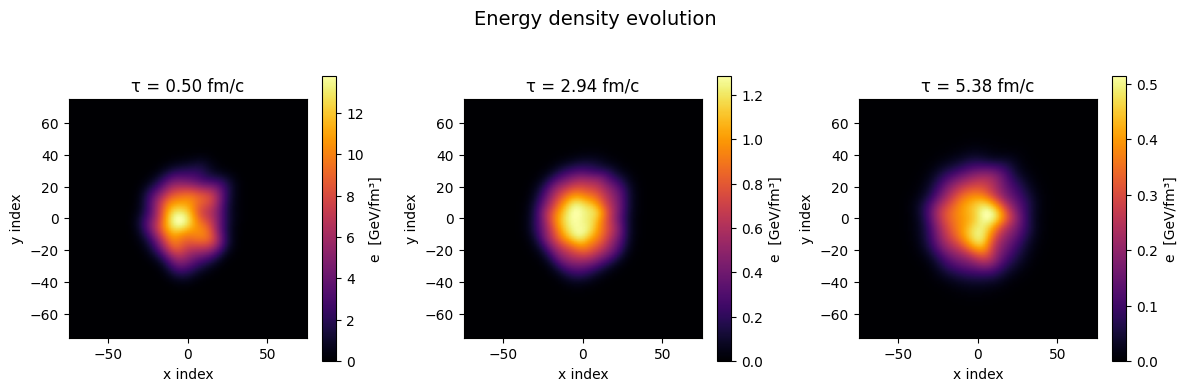

In [12]:
plot_energy_density_slices(arr, dtau, tau_min, "./", plt)